In [2]:
import os
from logging import INFO
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pyarrow as pa
import pyarrow.compute as pc
import random

from flwr.common import log

# Change font to respect submission requirements
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"
plt.rcParams["font.size"] = 14
plt.rcParams["font.weight"] = "bold"

# srun -w mauao -c 5 --partition=interactive --pty bash
# srun -w ngongotaha -c 5 --partition=interactive --pty bash
# poetry shell
# jupyter server --no-browser --port=8889
# ssh -L 8889:localhost:8889 ls985@mauao
# ssh -L 8889:localhost:8889 ls985@ngongotaha
HOME_DIR = Path(f"{os.getenv('HOME', '')}")

In [3]:
RESULTS_DIR = Path(f"{HOME_DIR}/projects/pollen_worker/results")

In [4]:
FRAMEWORKS = [
    "Pollen",
    "Pollen-RR",
    "Pollen-BB",
    "Parrot",
    "Flower",
    "FedScale",
    "Flute",
]  # New labels
# FRAMEWORKS = ['Pollen', 'Pollen-RR', 'Pollen-BB'] # New labels

In [5]:
DATASETS = ["TG", "IC", "SR", "MLM"]

In [6]:
DATASETS_FLWR = {
    "openimage": "IC",
    "google_speech": "SR",
    "shakespeare_memory": "TG",
    "reddit": "MLM",
}

DATASETS_FEDSCALE = {
    "openimage": "IC",
    "google_speech": "SR",
    "shakespeare": "TG",
    "reddit": "MLM",
}

DATASETS_FLUTE = {
    "openImg": "IC",
    "google_speech": "SR",
    "shakespeare": "TG",
    "reddit": "MLM",
}

In [7]:
HARDWARE_SETTINGS = {
    1: "1 GPU",
    2: "1+3 GPUs",
}

In [8]:
N_TOTAL_ROUNDS = 5_000

In [9]:
SCALES = {
    "IC": {
        100: "Medium Scale",
        1_000: "Large Scale",
        10_000: "Very Large Scale",
    },
    "SR": {
        100: "Medium Scale",
        1_000: "Large Scale",
        2_000: "Very Large Scale",
    },
    "TG": {
        100: "Medium Scale",
        1_000: "Large Scale",
        10_000: "Very Large Scale",
    },
    "MLM": {
        100: "Medium Scale",
        1_000: "Large Scale",
    },
}

In [10]:
TEXTURES = ["", ".", "x", "O", "/", "*", "|"]
COLORS = [
    sns.color_palette("colorblind")[3],
    sns.color_palette("colorblind")[1],
    sns.color_palette("colorblind")[2],
    sns.color_palette("colorblind")[0],
    sns.color_palette("colorblind")[7],
    sns.color_palette("colorblind")[4],
    sns.color_palette("colorblind")[5],
]

In [11]:
def error_bar_fn_std_based(x) -> tuple[float, float]:
    return (
        np.sum(x) - np.sqrt(N_TOTAL_ROUNDS * (5 * np.std(x)) ** 2),
        np.sum(x) + np.sqrt(N_TOTAL_ROUNDS * (5 * np.std(x)) ** 2),
    )

In [12]:
def error_bar_fn_min_max(x) -> tuple[float, float]:
    return (N_TOTAL_ROUNDS * np.min(x), N_TOTAL_ROUNDS * np.max(x))

In [13]:
def read_logs_flwr(log_file_path: Path) -> pa.Table | None:
    """Reads the log file and returns a pandas dataframe with the data."""
    # Init data for the table
    hardware_setting = 0  # 1 or 2
    n_clients_per_round = 0
    round_numbers: list[int] = []
    start_timestamp: list[pd.Timestamp] = []
    end_timestamp: list[pd.Timestamp] = []
    previous_timestamp: pd.Timestamp | None = None
    # Opening log file
    with open(log_file_path) as f:
        lines = f.readlines()
    while previous_timestamp is None:
        line = lines.pop(0)
        if line.startswith("[") and "global_state_accessor.cc:356:" not in line.split(
            " "
        ):
            strings = line.split(" ")
            while "" in strings:
                strings.remove("")
            # Reading first timestamp
            date = strings[0].replace("[", "")
            time = strings[1].split("]")[0]
            previous_timestamp = pd.to_datetime(
                f"{date} {time}", format="%Y-%m-%d %H:%M:%S,%f"
            )
            # Reading dataset
            dataset = DATASETS_FLWR[strings[5]]
            # Reading framework
            framework = (
                "Flower"
                if log_file_path.name.startswith("R")
                else "Pollen-{}".format(
                    strings[13].split("=")[1].upper().replace("\n", "")
                )
            )
            framework = "Parrot" if framework == "Pollen-LLB" else framework
            framework = "Pollen" if framework == "Pollen-LB" else framework
            framework = "Pollen-BB" if framework == "Pollen-BU" else framework
    # Reading log file
    cnt = 0
    for line in lines:
        if line.startswith("["):
            strings = line.split(" ")
            while "" in strings:
                strings.remove("")

            if hardware_setting == 0:
                if framework == "Flower" and "'GPU':" in strings:
                    idx = strings.index("'GPU':")
                    hardware_setting = (
                        1 if int(strings[idx + 1].split(".")[0]) == 1 else 2
                    )
                elif framework.startswith("P") and (
                    "sending" in strings and "instructions" in strings
                ):
                    hardware_setting = int(strings[8])

            if ("fit_round" in strings) and ("strategy" in strings):
                date = strings[0].replace("[", "")
                time = strings[1].split("]")[0]
                last_timestamp = pd.to_datetime(
                    f"{date} {time}", format="%Y-%m-%d %H:%M:%S,%f"
                )
                if n_clients_per_round == 0:
                    n_clients_per_round = int(strings[7])
                round_numbers.append(cnt)
                cnt += 1
                start_timestamp.append(previous_timestamp)
                previous_timestamp = last_timestamp
                end_timestamp.append(last_timestamp)
    # Creating dict to pass to pa.Table builder
    dict_for_table = {
        "rct": [
            (t1 - t0) for t0, t1 in zip(start_timestamp, end_timestamp, strict=False)
        ],
        "round": round_numbers,
        "n_clients_per_round": [n_clients_per_round] * len(round_numbers),
        "dataset": [dataset] * len(round_numbers),
        "framework": [framework] * len(round_numbers),
        "hardware_setting": [hardware_setting] * len(round_numbers),
        "is_dropped": [False] * len(round_numbers),
    }
    # Returning pa.Table
    return pa.Table.from_pydict(dict_for_table)

In [14]:
def read_logs_fedscale(log_file_path: Path) -> pa.Table | None:
    """Reads the log file and returns a pandas dataframe with the data."""
    # Init data for the table
    hardware_setting = 0  # 1 or 2
    n_clients_per_round = 0
    round_numbers: list[int] = []
    start_timestamp: list[pd.Timestamp] = []
    end_timestamp: list[pd.Timestamp] = []
    is_dropped: list[bool] = []
    previous_timestamp: pd.Timestamp | None = None
    # Opening log file
    with open(log_file_path) as f:
        lines = f.readlines()
    # Reading first configuration line
    line = lines.pop(0)
    strings = line.split(" ")
    while "" in strings:
        strings.remove("")
    # Reading first timestamp
    date = strings[0]  # format is "(mm-dd)"
    time = strings[1]  # format is "hh:mm:ss"
    previous_timestamp = pd.to_datetime(
        f"(2023-{date}) {time}", format="(%Y-(%m-%d)) %H:%M:%S"
    )
    # Reading dataset
    dataset = DATASETS_FEDSCALE[strings[6].split("'")[1].split("-")[0]]
    # Reading framework
    framework = "FedScale"
    # Reading the hardware setting
    hardware_setting = len(strings[16].split("'")[1].split("="))
    # Reading log file
    cnt = 0
    for line in lines:
        to_be_discarded = False
        strings = line.split(" ")
        while "" in strings:
            strings.remove("")
        if "morons." in strings:
            to_be_discarded = True
        if (
            ("Empty" in strings)
            and ("results" in strings)
            and ("from" in strings)
            and ("client" in strings)
        ):
            to_be_discarded = True
        if "[aggregator.py:543]" in strings and "round:" in strings:
            date = strings[0]  # format is "(mm-dd)"
            time = strings[1]  # format is "hh:mm:ss"
            last_timestamp = pd.to_datetime(
                f"(2023-{date}) {time}", format="(%Y-(%m-%d)) %H:%M:%S"
            )
            if to_be_discarded:
                print(
                    f"Round {cnt} to be discarded due to morons or failed"
                    " deserilization"
                )
            if n_clients_per_round == 0:
                n_clients_per_round = int(strings[15].replace(",", ""))
            to_be_discarded = False
            round_numbers.append(cnt)
            cnt += 1
            start_timestamp.append(previous_timestamp)
            previous_timestamp = last_timestamp
            end_timestamp.append(last_timestamp)
            is_dropped.append(to_be_discarded)
    # Creating dict to pass to pa.Table builder
    dict_for_table = {
        "rct": [
            (t1 - t0) for t0, t1 in zip(start_timestamp, end_timestamp, strict=False)
        ],
        "round": round_numbers,
        "n_clients_per_round": [n_clients_per_round] * len(round_numbers),
        "dataset": [dataset] * len(round_numbers),
        "framework": [framework] * len(round_numbers),
        "hardware_setting": [hardware_setting] * len(round_numbers),
        "is_dropped": is_dropped,
    }
    # Returning pa.Table
    return pa.Table.from_pydict(dict_for_table)

In [15]:
def read_logs_flute(log_file_path: Path):
    """Reads the log file and returns a pandas dataframe with the data."""
    # Init data for the table
    n_clients_per_round = 0
    round_numbers: list[int] = []
    start_timestamp: list[pd.Timestamp] = []
    end_timestamp: list[pd.Timestamp] = []
    previous_timestamp: pd.Timestamp | None = None
    # Opening log file
    with open(log_file_path) as f:
        lines = f.readlines()
    # Reading the hardware setting
    line = lines.pop(3)
    hardware_setting = 1 if int(line[-2]) == 1 else 2
    # Reading dataset
    line = lines.pop(4)
    strings = line.split(" ")
    dataset = DATASETS_FLUTE[strings[5].replace("'", "").replace(",", "")]
    # Reading framework
    framework = "Flute"
    # Reading the first timestamp
    while previous_timestamp is None:
        line = lines.pop(0)
        strings = line.split(" ")
        while "" in strings:
            strings.remove("")
        if "Assigning" in strings and "default" in strings and "values" in strings:
            datestring = line.split(" : ")[0].replace(" ", "-")
            previous_timestamp = pd.to_datetime(
                datestring, format="%a-%b-%d-%H:%M:%S-%Y"
            )
    # Reading log file
    cnt = 0
    for line in lines:
        strings = line.split(" ")
        if n_clients_per_round == 0:
            if "Clients" in strings and "for" in strings and "round" in strings:
                n_clients_per_round = int(strings[9])
        if "iteration" in strings:
            datestring = line.split(" : ")[0].replace(" ", "-")
            last_timestamp = pd.to_datetime(datestring, format="%a-%b-%d-%H:%M:%S-%Y")
            round_numbers.append(cnt)
            cnt += 1
            start_timestamp.append(previous_timestamp)
            previous_timestamp = last_timestamp
            end_timestamp.append(last_timestamp)
    # Creating dict to pass to pa.Table builder
    dict_for_table = {
        "rct": [
            (t1 - t0) for t0, t1 in zip(start_timestamp, end_timestamp, strict=False)
        ],
        "round": round_numbers,
        "n_clients_per_round": [n_clients_per_round] * len(round_numbers),
        "dataset": [dataset] * len(round_numbers),
        "framework": [framework] * len(round_numbers),
        "hardware_setting": [hardware_setting] * len(round_numbers),
        "is_dropped": [False] * len(round_numbers),
    }
    # Returning pa.Table
    return pa.Table.from_pydict(dict_for_table)

In [16]:
results_table: pa.Table | None = None
for result_file in RESULTS_DIR.glob("*"):
    tmp_table: pa.Table | None = None
    filename = result_file.name
    try:
        if filename.startswith("log"):
            tmp_table = read_logs_fedscale(result_file)
        elif filename.startswith("flute"):
            tmp_table = read_logs_flute(result_file)
        else:
            tmp_table = read_logs_flwr(result_file)
        if tmp_table is not None:
            if results_table is None:
                results_table = tmp_table
            else:
                results_table = pa.concat_tables(
                    [results_table, tmp_table],
                )
    except Exception as e:
        print(f"Error while reading {filename}: {e}")

INFO flwr 2024-01-22 23:59:38,240 | 3799812304.py:21 | For Pollen and TG the mean RCT (100 clients) is 3.815+-3.9065553880624813
INFO flwr 2024-01-22 23:59:38,260 | 3799812304.py:21 | For Pollen and IC the mean RCT (100 clients) is 22.1672+-4.908772164197479
INFO flwr 2024-01-22 23:59:38,271 | 3799812304.py:21 | For Pollen and SR the mean RCT (100 clients) is 25.6764+-6.306352594011851
INFO flwr 2024-01-22 23:59:38,282 | 3799812304.py:21 | For Pollen and MLM the mean RCT (100 clients) is 38.975+-3.5599964887623137
INFO flwr 2024-01-22 23:59:38,292 | 3799812304.py:21 | For Pollen-RR and TG the mean RCT (100 clients) is 3.7246+-4.251441501420429
INFO flwr 2024-01-22 23:59:38,304 | 3799812304.py:21 | For Pollen-RR and IC the mean RCT (100 clients) is 22.0726+-4.230570793640026
INFO flwr 2024-01-22 23:59:38,316 | 3799812304.py:21 | For Pollen-RR and SR the mean RCT (100 clients) is 28.1384+-5.92800518218397
INFO flwr 2024-01-22 23:59:38,327 | 3799812304.py:21 | For Pollen-RR and MLM the me

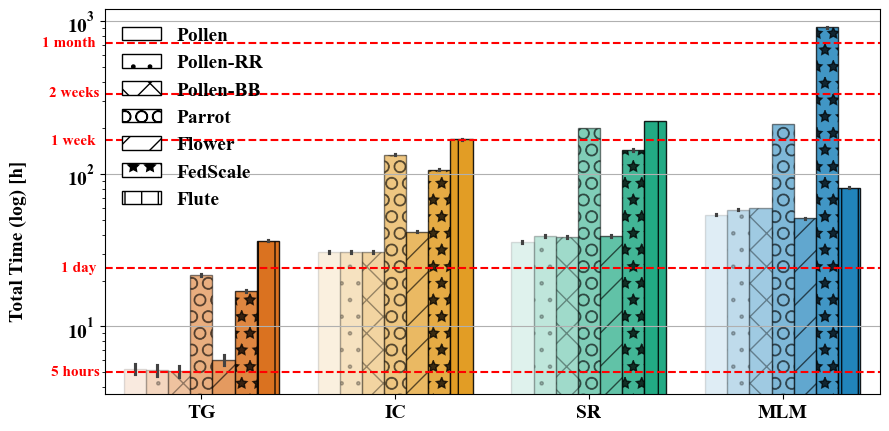

In [17]:
# Drawing bar plots for each dataset, hardware setting = 1 and 100 clients per round
current_hardware_setting = 1
n_clients_per_round = 100
dfs: list[pd.DataFrame] = []
for framework in FRAMEWORKS:
    for dataset in DATASETS:
        random.seed(1337)
        tmp_table = (
            results_table.filter(pc.field("framework") == pc.scalar(framework))
            .filter(pc.field("dataset") == pc.scalar(dataset))
            .filter(pc.field("hardware_setting") == pc.scalar(current_hardware_setting))
            .filter(pc.field("n_clients_per_round") == pc.scalar(n_clients_per_round))
            .filter(pc.field("is_dropped") == pc.scalar(False))
        )
        try:
            if tmp_table.num_rows != 0:
                tmp_rct = (
                    tmp_table.column("rct")
                    .to_numpy()[1:]
                    .astype("timedelta64[s]")
                    .astype(float)
                )
                tmp_rct = random.choices(tmp_rct, k=N_TOTAL_ROUNDS)
                tmp_dict = {
                    "Round Completion Time [s]": tmp_rct,
                    "Round Completion Time [m]": np.array(tmp_rct) * (1 / 60),
                    "Round Completion Time [h]": np.array(tmp_rct) * (1 / 3600),
                    "Round Completion Time [d]": (
                        np.array(tmp_rct) * (1 / 3600) * (1 / 24)
                    ),
                    "Framework": [framework] * N_TOTAL_ROUNDS,
                    "Dataset": [dataset] * N_TOTAL_ROUNDS,
                }
                log(
                    INFO,
                    f"For {framework} and {dataset} the mean RCT (100 clients) is"
                    f" {np.mean(tmp_rct)}+-{np.std(tmp_rct)}",
                )
                dfs.append(pd.DataFrame.from_dict(tmp_dict))
        except Exception as e:
            print(e)
df = pd.concat(dfs)
alpha_split = 1.0 / (len(df["Framework"].unique()) + 1)
alphas = [alpha_split * (i + 1) for i in range(len(df["Framework"].unique()))]
fig, ax = plt.subplots(figsize=(10, 5))
barplot = sns.barplot(
    data=df,
    x="Dataset",
    y="Round Completion Time [h]",
    order=DATASETS,
    hue="Framework",
    hue_order=FRAMEWORKS,
    errorbar=error_bar_fn_std_based,
    # errorbar=error_bar_fn_min_max,
    estimator=np.sum,
    ax=ax,
    edgecolor="black",
)
split = len(df["Framework"].unique()) * len(df["Dataset"].unique()) - 1
for i, patch in enumerate(ax.patches):
    if i > split:
        patch.set_facecolor("w")
        patch.set_hatch(TEXTURES[(i - split - 1) % len(TEXTURES)])
        patch.set_alpha(1.0)
    else:
        patch.set_facecolor(COLORS[i % (len(df["Dataset"].unique()))])
        patch.set_hatch(TEXTURES[i // (len(df["Dataset"].unique()))])
        patch.set_alpha(alphas[i // (len(df["Dataset"].unique()))])
y_axis_position = plt.gca().get_position().x0
plt.axhline(y=5, color="r", linestyle="--")
plt.text(y_axis_position - 0.9, 4.8, "5 hours", color="r", fontsize=11)
plt.axhline(y=24, color="r", linestyle="--")
plt.text(y_axis_position - 0.85, 23, "1 day", color="r", fontsize=11)
plt.axhline(y=24 * 7, color="r", linestyle="--")
plt.text(y_axis_position - 0.9, (24 * 7) - 12, "1 week", color="r", fontsize=11)
plt.axhline(y=24 * 14, color="r", linestyle="--")
plt.text(y_axis_position - 0.91, (24 * 14) - 14, "2 weeks", color="r", fontsize=11)
plt.axhline(y=24 * 30, color="r", linestyle="--")
plt.text(y_axis_position - 0.95, (24 * 30) - 30, "1 month", color="r", fontsize=11)
y_label = plt.ylabel("Total Time (log) [h]")
y_label.set_weight("bold")
plt.xlabel("")
ax.yaxis.set_label_coords(-0.1, 0.4)
plt.yscale("log")
plt.legend().set_title("")
legend_rect = plt.legend(loc="upper left").get_frame()
legend_rect.set_alpha(0)
plt.grid(axis="y")
plt.savefig(
    "inv_frameworks_singlenode_rebuttal.pdf", format="pdf", dpi=800, bbox_inches="tight"
)
plt.savefig(
    "inv_frameworks_singlenode_rebuttal.png", format="png", dpi=800, bbox_inches="tight"
)
plt.show()

INFO flwr 2024-01-22 23:59:41,458 | 1611448270.py:21 | For Pollen and TG the mean RCT (100 clients) is 3.815+-3.9065553880624813
INFO flwr 2024-01-22 23:59:41,473 | 1611448270.py:21 | For Pollen and IC the mean RCT (100 clients) is 22.1672+-4.908772164197479
INFO flwr 2024-01-22 23:59:41,483 | 1611448270.py:21 | For Pollen and SR the mean RCT (100 clients) is 25.6764+-6.306352594011851
INFO flwr 2024-01-22 23:59:41,494 | 1611448270.py:21 | For Pollen and MLM the mean RCT (100 clients) is 38.975+-3.5599964887623137
INFO flwr 2024-01-22 23:59:41,504 | 1611448270.py:21 | For Pollen-RR and TG the mean RCT (100 clients) is 3.7246+-4.251441501420429
INFO flwr 2024-01-22 23:59:41,516 | 1611448270.py:21 | For Pollen-RR and IC the mean RCT (100 clients) is 22.0726+-4.230570793640026
INFO flwr 2024-01-22 23:59:41,528 | 1611448270.py:21 | For Pollen-RR and SR the mean RCT (100 clients) is 28.1384+-5.92800518218397
INFO flwr 2024-01-22 23:59:41,537 | 1611448270.py:21 | For Pollen-RR and MLM the me

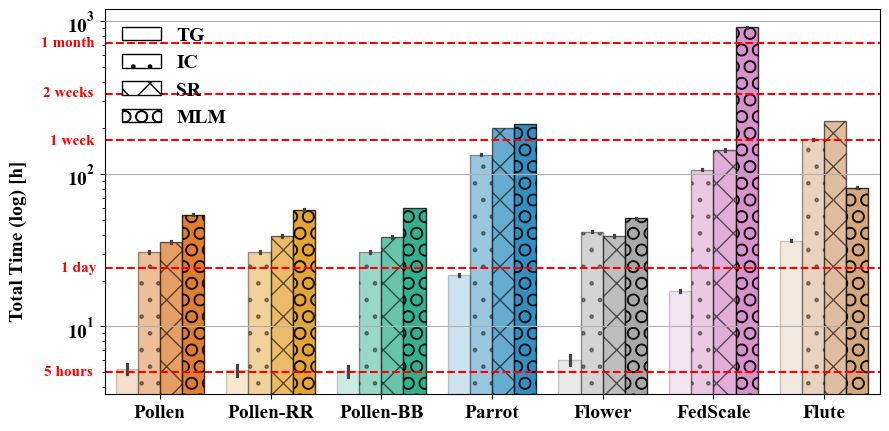

In [18]:
# Drawing bar plots for each dataset, hardware setting = 1 and 100 clients per round
current_hardware_setting = 1
n_clients_per_round = 100
dfs: list[pd.DataFrame] = []
for framework in FRAMEWORKS:
    for dataset in DATASETS:
        random.seed(1337)
        tmp_table = (
            results_table.filter(pc.field("framework") == pc.scalar(framework))
            .filter(pc.field("dataset") == pc.scalar(dataset))
            .filter(pc.field("hardware_setting") == pc.scalar(current_hardware_setting))
            .filter(pc.field("n_clients_per_round") == pc.scalar(n_clients_per_round))
            .filter(pc.field("is_dropped") == pc.scalar(False))
        )
        try:
            if tmp_table.num_rows != 0:
                tmp_rct = (
                    tmp_table.column("rct")
                    .to_numpy()[1:]
                    .astype("timedelta64[s]")
                    .astype(float)
                )
                tmp_rct = random.choices(tmp_rct, k=N_TOTAL_ROUNDS)
                tmp_dict = {
                    "Round Completion Time [s]": tmp_rct,
                    "Round Completion Time [m]": np.array(tmp_rct) * (1 / 60),
                    "Round Completion Time [h]": np.array(tmp_rct) * (1 / 3600),
                    "Round Completion Time [d]": (
                        np.array(tmp_rct) * (1 / 3600) * (1 / 24)
                    ),
                    "Framework": [framework] * N_TOTAL_ROUNDS,
                    "Dataset": [dataset] * N_TOTAL_ROUNDS,
                }
                log(
                    INFO,
                    f"For {framework} and {dataset} the mean RCT (100 clients) is"
                    f" {np.mean(tmp_rct)}+-{np.std(tmp_rct)}",
                )
                dfs.append(pd.DataFrame.from_dict(tmp_dict))
        except Exception as e:
            print(e)
df = pd.concat(dfs)
alpha_split = 1.0 / (len(df["Dataset"].unique()) + 1)
alphas = [alpha_split * (i + 1) for i in range(len(df["Dataset"].unique()))]
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=df,
    x="Framework",
    y="Round Completion Time [h]",
    order=FRAMEWORKS,
    hue="Dataset",
    hue_order=DATASETS,
    errorbar=error_bar_fn_std_based,
    # errorbar=error_bar_fn_min_max,
    estimator=np.sum,
    ax=ax,
    edgecolor="black",
)
split = len(df["Framework"].unique()) * len(df["Dataset"].unique()) - 1
for i, patch in enumerate(ax.patches):
    if i > split:
        patch.set_facecolor("w")
        patch.set_hatch(TEXTURES[(i - split - 1) % len(TEXTURES)])
        patch.set_alpha(1.0)
    else:
        patch.set_facecolor(COLORS[i % (len(df["Framework"].unique()))])
        patch.set_hatch(TEXTURES[i // (len(df["Framework"].unique()))])
        patch.set_alpha(alphas[i // (len(df["Framework"].unique()))])
y_axis_position = plt.gca().get_position().x0
plt.axhline(y=5, color="r", linestyle="--")
plt.text(y_axis_position - 1.17, 4.8, "5 hours", color="r", fontsize=11)
plt.axhline(y=24, color="r", linestyle="--")
plt.text(y_axis_position - 1.02, 23, "1 day", color="r", fontsize=11)
plt.axhline(y=24 * 7, color="r", linestyle="--")
plt.text(y_axis_position - 1.12, (24 * 7) - 12, "1 week", color="r", fontsize=11)
plt.axhline(y=24 * 14, color="r", linestyle="--")
plt.text(y_axis_position - 1.18, (24 * 14) - 14, "2 weeks", color="r", fontsize=11)
plt.axhline(y=24 * 30, color="r", linestyle="--")
plt.text(y_axis_position - 1.20, (24 * 30) - 30, "1 month", color="r", fontsize=11)
y_label = plt.ylabel("Total Time (log) [h]")
y_label.set_weight("bold")
plt.xlabel("")
ax.yaxis.set_label_coords(-0.1, 0.4)
plt.yscale("log")
plt.legend().set_title("")
legend_rect = plt.legend(loc="upper left").get_frame()
legend_rect.set_alpha(0)
plt.grid(axis="y")
plt.savefig(
    "frameworks_singlenode_rebuttal.pdf", format="pdf", dpi=800, bbox_inches="tight"
)
plt.savefig(
    "frameworks_singlenode_rebuttal.png", format="png", dpi=800, bbox_inches="tight"
)
plt.show()

INFO flwr 2024-01-22 23:59:44,238 | 3557229150.py:20 | For Pollen and TG the mean RCT (100 clients) is 1.6824+-3.1322085243482753
INFO flwr 2024-01-22 23:59:44,253 | 3557229150.py:20 | For Pollen and IC the mean RCT (100 clients) is 11.4968+-4.464256910169933
INFO flwr 2024-01-22 23:59:44,267 | 3557229150.py:20 | For Pollen and SR the mean RCT (100 clients) is 17.5866+-6.310760686319835
INFO flwr 2024-01-22 23:59:44,281 | 3557229150.py:20 | For Pollen and MLM the mean RCT (100 clients) is 22.73+-4.163063775634479
INFO flwr 2024-01-22 23:59:44,294 | 3557229150.py:20 | For Pollen-RR and TG the mean RCT (100 clients) is 2.4726+-2.61939864090978
INFO flwr 2024-01-22 23:59:44,310 | 3557229150.py:20 | For Pollen-RR and IC the mean RCT (100 clients) is 13.6544+-3.704721398432006
INFO flwr 2024-01-22 23:59:44,322 | 3557229150.py:20 | For Pollen-RR and SR the mean RCT (100 clients) is 16.9578+-6.714105983673479
INFO flwr 2024-01-22 23:59:44,333 | 3557229150.py:20 | For Pollen-RR and MLM the mea

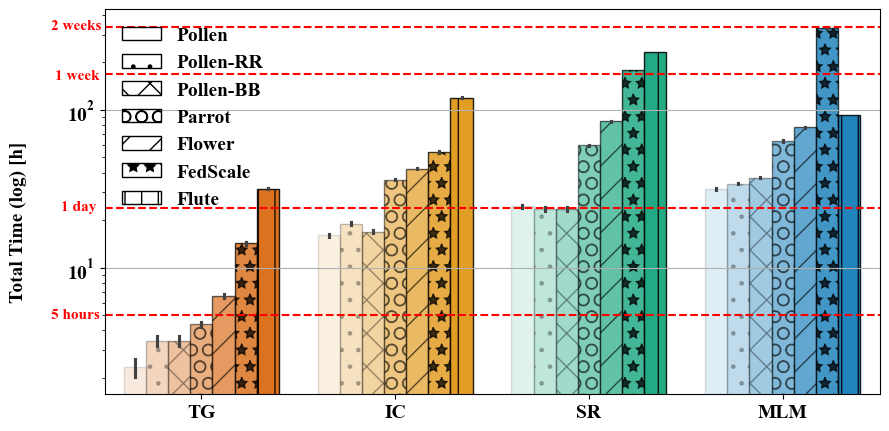

In [19]:
# Drawing bar plots for each dataset, hardware setting = 2 and 100 clients per round
current_hardware_setting = 2
n_clients_per_round = 100
dfs: list[pd.DataFrame] = []
for framework in FRAMEWORKS:
    for dataset in DATASETS:
        random.seed(1337)
        tmp_table = (
            results_table.filter(pc.field("framework") == pc.scalar(framework))
            .filter(pc.field("dataset") == pc.scalar(dataset))
            .filter(pc.field("hardware_setting") == pc.scalar(current_hardware_setting))
            .filter(pc.field("n_clients_per_round") == pc.scalar(n_clients_per_round))
            .filter(pc.field("is_dropped") == pc.scalar(False))
        )
        try:
            if tmp_table.num_rows != 0:
                tmp_rct = (
                    tmp_table.column("rct")
                    .to_numpy()[1:]
                    .astype("timedelta64[s]")
                    .astype(float)
                )
                tmp_rct = random.choices(tmp_rct, k=N_TOTAL_ROUNDS)
                tmp_dict = {
                    "Round Completion Time [s]": tmp_rct,
                    "Round Completion Time [m]": np.array(tmp_rct) * (1 / 60),
                    "Round Completion Time [h]": np.array(tmp_rct) * (1 / 3600),
                    "Framework": [framework] * N_TOTAL_ROUNDS,
                    "Dataset": [dataset] * N_TOTAL_ROUNDS,
                }
                log(
                    INFO,
                    f"For {framework} and {dataset} the mean RCT (100 clients) is"
                    f" {np.mean(tmp_rct)}+-{np.std(tmp_rct)}",
                )
                dfs.append(pd.DataFrame.from_dict(tmp_dict))
        except Exception as e:
            print(e)
df = pd.concat(dfs)
alpha_split = 1.0 / (len(df["Framework"].unique()) + 1)
alphas = [alpha_split * (i + 1) for i in range(len(df["Framework"].unique()))]
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=df,
    x="Dataset",
    y="Round Completion Time [h]",
    order=DATASETS,
    hue="Framework",
    hue_order=FRAMEWORKS,
    errorbar=error_bar_fn_std_based,
    # errorbar=error_bar_fn_min_max,
    estimator=np.sum,
    ax=ax,
    edgecolor="black",
)
split = len(df["Framework"].unique()) * len(df["Dataset"].unique()) - 1
for i, patch in enumerate(ax.patches):
    if i > split:
        patch.set_facecolor("w")
        patch.set_hatch(TEXTURES[(i - split - 1) % len(TEXTURES)])
        patch.set_alpha(1.0)
    else:
        patch.set_facecolor(COLORS[i % (len(df["Dataset"].unique()))])
        patch.set_hatch(TEXTURES[i // (len(df["Dataset"].unique()))])
        patch.set_alpha(alphas[i // (len(df["Dataset"].unique()))])
y_axis_position = plt.gca().get_position().x0
plt.axhline(y=5, color="r", linestyle="--")
plt.text(y_axis_position - 0.9, 4.8, "5 hours", color="r", fontsize=11)
plt.axhline(y=24, color="r", linestyle="--")
plt.text(y_axis_position - 0.85, 23, "1 day", color="r", fontsize=11)
plt.axhline(y=24 * 7, color="r", linestyle="--")
plt.text(y_axis_position - 0.88, (24 * 7) - 12, "1 week", color="r", fontsize=11)
plt.axhline(y=24 * 14, color="r", linestyle="--")
plt.text(y_axis_position - 0.9, (24 * 14) - 14, "2 weeks", color="r", fontsize=11)
y_label = plt.ylabel("Total Time (log) [h]")
y_label.set_weight("bold")
plt.xlabel("")
ax.yaxis.set_label_coords(-0.1, 0.45)
plt.yscale("log")
plt.legend().set_title("")
legend_rect = plt.legend(loc="upper left").get_frame()
legend_rect.set_alpha(0)
plt.grid(axis="y")
plt.savefig(
    "inv_frameworks_multinode_rebuttal.pdf", format="pdf", dpi=800, bbox_inches="tight"
)
plt.savefig(
    "inv_frameworks_multinode_rebuttal.png", format="png", dpi=800, bbox_inches="tight"
)
plt.show()

INFO flwr 2024-01-22 23:59:46,977 | 2815114917.py:20 | For Pollen and TG the mean RCT (100 clients) is 1.6824+-3.1322085243482753
INFO flwr 2024-01-22 23:59:46,992 | 2815114917.py:20 | For Pollen and IC the mean RCT (100 clients) is 11.4968+-4.464256910169933
INFO flwr 2024-01-22 23:59:47,009 | 2815114917.py:20 | For Pollen and SR the mean RCT (100 clients) is 17.5866+-6.310760686319835
INFO flwr 2024-01-22 23:59:47,025 | 2815114917.py:20 | For Pollen and MLM the mean RCT (100 clients) is 22.73+-4.163063775634479
INFO flwr 2024-01-22 23:59:47,038 | 2815114917.py:20 | For Pollen-RR and TG the mean RCT (100 clients) is 2.4726+-2.61939864090978
INFO flwr 2024-01-22 23:59:47,050 | 2815114917.py:20 | For Pollen-RR and IC the mean RCT (100 clients) is 13.6544+-3.704721398432006
INFO flwr 2024-01-22 23:59:47,061 | 2815114917.py:20 | For Pollen-RR and SR the mean RCT (100 clients) is 16.9578+-6.714105983673479
INFO flwr 2024-01-22 23:59:47,072 | 2815114917.py:20 | For Pollen-RR and MLM the mea

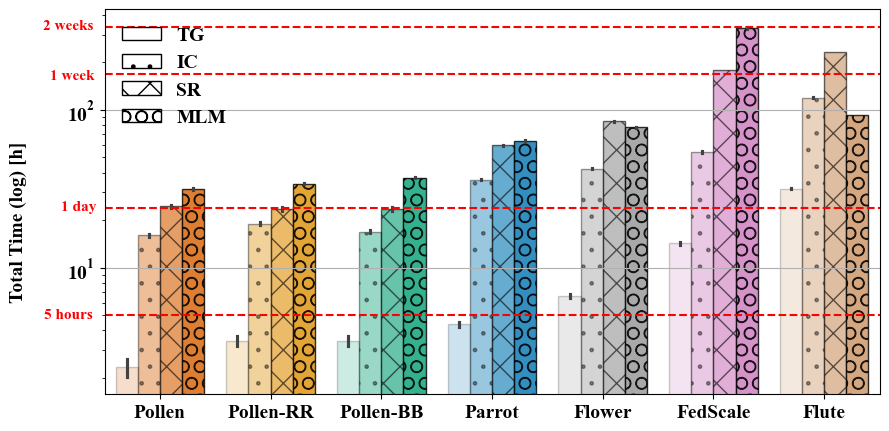

In [20]:
# Drawing bar plots for each dataset, hardware setting = 2 and 100 clients per round
current_hardware_setting = 2
n_clients_per_round = 100
dfs: list[pd.DataFrame] = []
for framework in FRAMEWORKS:
    for dataset in DATASETS:
        random.seed(1337)
        tmp_table = (
            results_table.filter(pc.field("framework") == pc.scalar(framework))
            .filter(pc.field("dataset") == pc.scalar(dataset))
            .filter(pc.field("hardware_setting") == pc.scalar(current_hardware_setting))
            .filter(pc.field("n_clients_per_round") == pc.scalar(n_clients_per_round))
            .filter(pc.field("is_dropped") == pc.scalar(False))
        )
        try:
            if tmp_table.num_rows != 0:
                tmp_rct = (
                    tmp_table.column("rct")
                    .to_numpy()[1:]
                    .astype("timedelta64[s]")
                    .astype(float)
                )
                tmp_rct = random.choices(tmp_rct, k=N_TOTAL_ROUNDS)
                tmp_dict = {
                    "Round Completion Time [s]": tmp_rct,
                    "Round Completion Time [m]": np.array(tmp_rct) * (1 / 60),
                    "Round Completion Time [h]": np.array(tmp_rct) * (1 / 3600),
                    "Framework": [framework] * N_TOTAL_ROUNDS,
                    "Dataset": [dataset] * N_TOTAL_ROUNDS,
                }
                log(
                    INFO,
                    f"For {framework} and {dataset} the mean RCT (100 clients) is"
                    f" {np.mean(tmp_rct)}+-{np.std(tmp_rct)}",
                )
                dfs.append(pd.DataFrame.from_dict(tmp_dict))
        except Exception as e:
            print(e)
df = pd.concat(dfs)
alpha_split = 1.0 / (len(df["Dataset"].unique()) + 1)
alphas = [alpha_split * (i + 1) for i in range(len(df["Dataset"].unique()))]
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=df,
    x="Framework",
    y="Round Completion Time [h]",
    order=FRAMEWORKS,
    hue="Dataset",
    hue_order=DATASETS,
    errorbar=error_bar_fn_std_based,
    # errorbar=error_bar_fn_min_max,
    estimator=np.sum,
    ax=ax,
    edgecolor="black",
)
split = len(df["Framework"].unique()) * len(df["Dataset"].unique()) - 1
for i, patch in enumerate(ax.patches):
    if i > split:
        patch.set_facecolor("w")
        patch.set_hatch(TEXTURES[(i - split - 1) % len(TEXTURES)])
        patch.set_alpha(1.0)
    else:
        patch.set_facecolor(COLORS[i % (len(df["Framework"].unique()))])
        patch.set_hatch(TEXTURES[i // (len(df["Framework"].unique()))])
        patch.set_alpha(alphas[i // (len(df["Framework"].unique()))])
y_axis_position = plt.gca().get_position().x0
plt.axhline(y=5, color="r", linestyle="--")
plt.text(y_axis_position - 1.17, 4.8, "5 hours", color="r", fontsize=11)
plt.axhline(y=24, color="r", linestyle="--")
plt.text(y_axis_position - 1.02, 23, "1 day", color="r", fontsize=11)
plt.axhline(y=24 * 7, color="r", linestyle="--")
plt.text(y_axis_position - 1.12, (24 * 7) - 12, "1 week", color="r", fontsize=11)
plt.axhline(y=24 * 14, color="r", linestyle="--")
plt.text(y_axis_position - 1.18, (24 * 14) - 14, "2 weeks", color="r", fontsize=11)
y_label = plt.ylabel("Total Time (log) [h]")
y_label.set_weight("bold")
plt.xlabel("")
ax.yaxis.set_label_coords(-0.1, 0.45)
plt.yscale("log")
plt.legend().set_title("")
legend_rect = plt.legend(loc="upper left").get_frame()
legend_rect.set_alpha(0)
plt.grid(axis="y")
plt.savefig(
    "frameworks_multinode_rebuttal.pdf", format="pdf", dpi=800, bbox_inches="tight"
)
plt.savefig(
    "frameworks_multinode_rebuttal.png", format="png", dpi=800, bbox_inches="tight"
)
plt.show()

INFO flwr 2024-01-22 23:59:49,743 | 2844571121.py:45 | For Pollen and TG the mean RCT (100 clients) is 1.6844+-0.0006269927157471607


INFO flwr 2024-01-22 23:59:49,755 | 2844571121.py:45 | For Pollen and TG the mean RCT (1000 clients) is 17.6184+-0.001205480509008752
INFO flwr 2024-01-22 23:59:49,775 | 2844571121.py:45 | For Pollen and TG the mean RCT (10000 clients) is 164.4212+-0.003715729756373571
INFO flwr 2024-01-22 23:59:49,797 | 2844571121.py:45 | For Pollen-RR and TG the mean RCT (100 clients) is 2.4768+-0.0005270848796920662
INFO flwr 2024-01-22 23:59:49,816 | 2844571121.py:45 | For Pollen-RR and TG the mean RCT (1000 clients) is 19.0494+-0.0007351669100279202
INFO flwr 2024-01-22 23:59:49,830 | 2844571121.py:45 | For Pollen-RR and TG the mean RCT (10000 clients) is 184.4942+-0.0020383440961721845
INFO flwr 2024-01-22 23:59:49,844 | 2844571121.py:45 | For Pollen-BB and TG the mean RCT (100 clients) is 2.481+-0.0004917738911329068
INFO flwr 2024-01-22 23:59:49,857 | 2844571121.py:45 | For Pollen-BB and TG the mean RCT (1000 clients) is 18.5112+-0.0009111371918651987
INFO flwr 2024-01-22 23:59:49,869 | 2844571

Dataset: TG


INFO flwr 2024-01-22 23:59:49,941 | 2844571121.py:45 | For Flower and TG the mean RCT (10000 clients) is 511.2432+-0.00846116978617023
INFO flwr 2024-01-22 23:59:49,952 | 2844571121.py:45 | For FedScale and TG the mean RCT (100 clients) is 10.2576+-0.0005144955681053046
INFO flwr 2024-01-22 23:59:49,965 | 2844571121.py:45 | For FedScale and TG the mean RCT (1000 clients) is 56.0064+-0.0005941703136306964
INFO flwr 2024-01-22 23:59:49,977 | 2844571121.py:45 | For FedScale and TG the mean RCT (10000 clients) is 542.7664+-0.0017912211593212046
INFO flwr 2024-01-22 23:59:49,988 | 2844571121.py:45 | For Flute and TG the mean RCT (100 clients) is 22.8072+-0.0005693233935119828
INFO flwr 2024-01-22 23:59:50,000 | 2844571121.py:45 | For Flute and TG the mean RCT (1000 clients) is 213.9368+-0.0019178321695080618
INFO flwr 2024-01-22 23:59:50,012 | 2844571121.py:45 | For Flute and TG the mean RCT (10000 clients) is 2202.7184+-0.013728090765201111


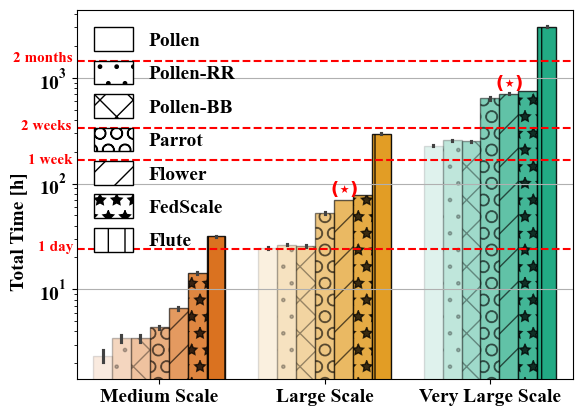

INFO flwr 2024-01-22 23:59:52,049 | 2844571121.py:45 | For Pollen and IC the mean RCT (100 clients) is 11.4992+-0.0008935502081024883
INFO flwr 2024-01-22 23:59:52,065 | 2844571121.py:45 | For Pollen and IC the mean RCT (1000 clients) is 102.58+-0.0031440305342028724
INFO flwr 2024-01-22 23:59:52,080 | 2844571121.py:45 | For Pollen and IC the mean RCT (10000 clients) is 1027.672+-0.014513833974522376
INFO flwr 2024-01-22 23:59:52,095 | 2844571121.py:45 | For Pollen-RR and IC the mean RCT (100 clients) is 13.6558+-0.0007413859011338158
INFO flwr 2024-01-22 23:59:52,114 | 2844571121.py:45 | For Pollen-RR and IC the mean RCT (1000 clients) is 120.1358+-0.00184491689091948
INFO flwr 2024-01-22 23:59:52,129 | 2844571121.py:45 | For Pollen-RR and IC the mean RCT (10000 clients) is 1109.28+-0.0037570286131462993
INFO flwr 2024-01-22 23:59:52,143 | 2844571121.py:45 | For Pollen-BB and IC the mean RCT (100 clients) is 12.1728+-0.0006013498203209177
INFO flwr 2024-01-22 23:59:52,156 | 2844571121

Dataset: IC


INFO flwr 2024-01-22 23:59:52,245 | 2844571121.py:45 | For Flower and IC the mean RCT (10000 clients) is 2957.1322+-0.07916505813126394
INFO flwr 2024-01-22 23:59:52,258 | 2844571121.py:45 | For FedScale and IC the mean RCT (100 clients) is 38.8848+-0.0014498707385142994
INFO flwr 2024-01-22 23:59:52,270 | 2844571121.py:45 | For FedScale and IC the mean RCT (1000 clients) is 301.4786+-0.01199607992977706
INFO flwr 2024-01-22 23:59:52,291 | 2844571121.py:45 | For Flute and IC the mean RCT (100 clients) is 86.0998+-0.0016306150981761451
INFO flwr 2024-01-22 23:59:52,302 | 2844571121.py:45 | For Flute and IC the mean RCT (1000 clients) is 803.9464+-0.007169838846278206
INFO flwr 2024-01-22 23:59:52,314 | 2844571121.py:45 | For Flute and IC the mean RCT (10000 clients) is 9112.957+-0.03330158792069831


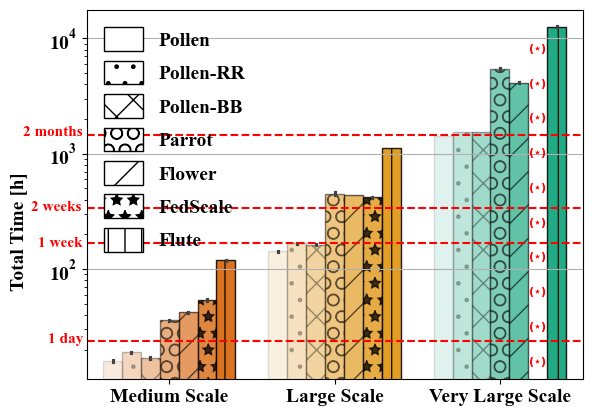

INFO flwr 2024-01-22 23:59:54,274 | 2844571121.py:45 | For Pollen and SR the mean RCT (100 clients) is 17.5926+-0.0012648893270163994
INFO flwr 2024-01-22 23:59:54,286 | 2844571121.py:45 | For Pollen and SR the mean RCT (1000 clients) is 139.925+-0.00606874146755322
INFO flwr 2024-01-22 23:59:54,298 | 2844571121.py:45 | For Pollen and SR the mean RCT (2000 clients) is 273.8648+-0.0072829766468388455
INFO flwr 2024-01-22 23:59:54,310 | 2844571121.py:45 | For Pollen-RR and SR the mean RCT (100 clients) is 16.964+-0.001345319352421573
INFO flwr 2024-01-22 23:59:54,323 | 2844571121.py:45 | For Pollen-RR and SR the mean RCT (1000 clients) is 154.1058+-0.0068723125841597165
INFO flwr 2024-01-22 23:59:54,335 | 2844571121.py:45 | For Pollen-RR and SR the mean RCT (2000 clients) is 289.9874+-0.005208626848757741
INFO flwr 2024-01-22 23:59:54,348 | 2844571121.py:45 | For Pollen-BB and SR the mean RCT (100 clients) is 16.8732+-0.0013040969559047363
INFO flwr 2024-01-22 23:59:54,360 | 2844571121.p

Dataset: SR


INFO flwr 2024-01-22 23:59:54,461 | 2844571121.py:45 | For FedScale and SR the mean RCT (1000 clients) is 1030.673+-0.0033900942228793584
INFO flwr 2024-01-22 23:59:54,473 | 2844571121.py:45 | For FedScale and SR the mean RCT (2000 clients) is 2021.1062+-0.006192284623820194
INFO flwr 2024-01-22 23:59:54,484 | 2844571121.py:45 | For Flute and SR the mean RCT (100 clients) is 167.2426+-0.002997140939228584
INFO flwr 2024-01-22 23:59:54,497 | 2844571121.py:45 | For Flute and SR the mean RCT (1000 clients) is 1514.1246+-0.017543064583863337
INFO flwr 2024-01-22 23:59:54,508 | 2844571121.py:45 | For Flute and SR the mean RCT (2000 clients) is 3422.5496+-0.013283931857458466


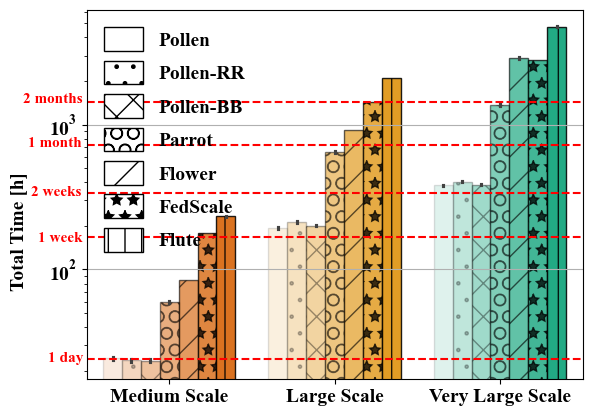

INFO flwr 2024-01-22 23:59:56,405 | 2844571121.py:45 | For Pollen and MLM the mean RCT (100 clients) is 22.7298+-0.0008326245723013464
INFO flwr 2024-01-22 23:59:56,415 | 2844571121.py:45 | For Pollen and MLM the mean RCT (1000 clients) is 224.6666+-0.001174479364484536
INFO flwr 2024-01-22 23:59:56,428 | 2844571121.py:45 | For Pollen-RR and MLM the mean RCT (100 clients) is 24.4138+-0.0005945273605142156
INFO flwr 2024-01-22 23:59:56,441 | 2844571121.py:45 | For Pollen-RR and MLM the mean RCT (1000 clients) is 227.3892+-0.0009160550935396843
INFO flwr 2024-01-22 23:59:56,455 | 2844571121.py:45 | For Pollen-BB and MLM the mean RCT (100 clients) is 26.7426+-0.0004432762226873894
INFO flwr 2024-01-22 23:59:56,476 | 2844571121.py:45 | For Pollen-BB and MLM the mean RCT (1000 clients) is 248.797+-0.0012051653994369404
INFO flwr 2024-01-22 23:59:56,494 | 2844571121.py:45 | For Parrot and MLM the mean RCT (100 clients) is 45.5378+-0.0013219345091191167
INFO flwr 2024-01-22 23:59:56,507 | 284

Dataset: MLM


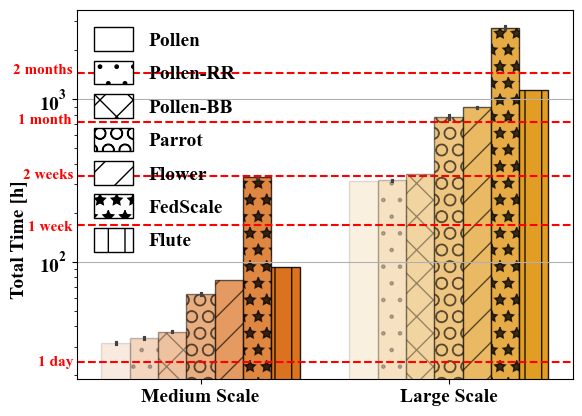

In [21]:
y_axis_label_coord = {
    "IC": [-0.12, 0.4],
    "SR": [-0.12, 0.4],
    "TG": [-0.1, 0.4],
    "MLM": [-0.1, 0.38],
}

texts_coord = {
    "IC": [0.86, 0.92, 0.96, 0.98, 1.01],
    "SR": [0.86, 0.92, 0.96, 0.98, 1.01],
    "TG": [0.86, 0.92, 0.96, 0.98, 1.01],
    "MLM": [0.78, 0.82, 0.84, 0.86, 0.88],
}

# Drawing bar plots for each dataset, hardware setting = 2 and 100 clients per round
current_hardware_setting = 2
for dataset in DATASETS:
    print(f"Dataset: {dataset}")
    dfs: list[pd.DataFrame] = []
    for framework in FRAMEWORKS:
        for n_clients_per_round, scale in SCALES[dataset].items():
            random.seed(1337)
            tmp_table = (
                results_table.filter(pc.field("framework") == pc.scalar(framework))
                .filter(pc.field("dataset") == pc.scalar(dataset))
                .filter(
                    pc.field("hardware_setting") == pc.scalar(current_hardware_setting)
                )
                .filter(
                    pc.field("n_clients_per_round") == pc.scalar(n_clients_per_round)
                )
                .filter(pc.field("is_dropped") == pc.scalar(False))
            )
            try:
                tmp_dict = {
                    "Round Completion Time [s]": [0.0] * N_TOTAL_ROUNDS,
                    "Round Completion Time [m]": [0.0] * N_TOTAL_ROUNDS,
                    "Round Completion Time [h]": [0.0] * N_TOTAL_ROUNDS,
                    "Framework": [framework] * N_TOTAL_ROUNDS,
                    "Dataset": [dataset] * N_TOTAL_ROUNDS,
                    "Scale (# clients per round)": [scale] * N_TOTAL_ROUNDS,
                }
                if tmp_table.num_rows != 0:
                    # tmp_rct = tmp_table.column('rct').to_numpy()[1:].astype('timedelta64[s]').astype(float)
                    tmp_rct = (
                        tmp_table.column("rct")
                        .to_numpy()
                        .astype("timedelta64[s]")
                        .astype(float)
                    )
                    tmp_rct = [tmp_rct[0]] + random.choices(
                        tmp_rct[1:], k=N_TOTAL_ROUNDS - 1
                    )
                    tmp_dict = {
                        "Round Completion Time [s]": tmp_rct,
                        "Round Completion Time [m]": np.array(tmp_rct) * (1 / 60),
                        "Round Completion Time [h]": np.array(tmp_rct) * (1 / 3600),
                        "Framework": [framework] * N_TOTAL_ROUNDS,
                        "Dataset": [dataset] * N_TOTAL_ROUNDS,
                        "Scale (# clients per round)": [scale] * N_TOTAL_ROUNDS,
                    }
                    log(
                        INFO,
                        f"For {framework} and {dataset} the mean RCT"
                        f" ({n_clients_per_round} clients) is"
                        f" {np.mean(tmp_rct)}+-{(np.std(tmp_rct)) / len(tmp_rct)}",
                    )
                dfs.append(pd.DataFrame.from_dict(tmp_dict))
            except Exception as e:
                print(e)
    df = pd.concat(dfs)
    alpha_split = 1.0 / (len(df["Framework"].unique()) + 1)
    alphas = [alpha_split * (i + 1) for i in range(len(df["Framework"].unique()))]
    fig, ax = plt.subplots()
    sns.barplot(
        data=df,
        x="Scale (# clients per round)",
        y="Round Completion Time [h]",
        hue="Framework",
        errorbar=error_bar_fn_std_based,
        # errorbar=error_bar_fn_min_max,
        estimator=np.sum,
        edgecolor="black",
    )
    split = (
        len(df["Framework"].unique()) * len(df["Scale (# clients per round)"].unique())
        - 1
    )
    for i, patch in enumerate(ax.patches):
        if i > split:
            patch.set_facecolor("w")
            patch.set_hatch(TEXTURES[(i - 1 - split) % len(TEXTURES)])
            patch.set_alpha(1.0)
        else:
            patch.set_facecolor(
                COLORS[i % (len(df["Scale (# clients per round)"].unique()))]
            )
            patch.set_hatch(
                TEXTURES[i // (len(df["Scale (# clients per round)"].unique()))]
            )
            patch.set_alpha(
                alphas[i // (len(df["Scale (# clients per round)"].unique()))]
            )
    y_axis_position = plt.gca().get_position().x0
    plt.axhline(y=24, color="r", linestyle="--")
    plt.text(
        y_axis_position - texts_coord[dataset][0], 23, "1 day", color="r", fontsize=11
    )
    plt.axhline(y=24 * 7, color="r", linestyle="--")
    plt.text(
        y_axis_position - texts_coord[dataset][1],
        (24 * 7) - 12,
        "1 week",
        color="r",
        fontsize=11,
    )
    plt.axhline(y=24 * 14, color="r", linestyle="--")
    plt.text(
        y_axis_position - texts_coord[dataset][2],
        (24 * 14) - 14,
        "2 weeks",
        color="r",
        fontsize=11,
    )
    if dataset == "SR" or dataset == "MLM":
        plt.axhline(y=24 * 30, color="r", linestyle="--")
        plt.text(
            y_axis_position - texts_coord[dataset][3],
            (24 * 30) - 14,
            "1 month",
            color="r",
            fontsize=11,
        )
    plt.axhline(y=24 * 60, color="r", linestyle="--")
    plt.text(
        y_axis_position - texts_coord[dataset][4],
        (24 * 60) - 14,
        "2 months",
        color="r",
        fontsize=11,
    )
    if len(FRAMEWORKS) == 7 and dataset == "TG":
        plt.text(1.03, 79, r"$(\star)$", color="red", fontsize=13)
        plt.text(2.03, 795, r"$(\star)$", color="red", fontsize=13)
    if len(FRAMEWORKS) == 7 and dataset == "IC":
        for i in range(10):
            plt.text(2.17, 15 * (2**i), r"$(\star)$", color="red", fontsize=8)

    y_label = plt.ylabel("Total Time [h]")
    y_label.set_weight("bold")
    ax.yaxis.set_label_coords(
        y_axis_label_coord[dataset][0],
        y_axis_label_coord[dataset][1],
    )
    plt.yscale("log")
    plt.xlabel("")
    legend = plt.legend(handleheight=1.5)
    legend.set_title("")
    legend.get_frame().set_alpha(0)
    plt.grid(axis="y")
    plt.savefig(
        f"scalability_{dataset.lower()}_rebuttal.pdf",
        format="pdf",
        dpi=800,
        bbox_inches="tight",
    )
    plt.savefig(
        f"scalability_{dataset.lower()}_rebuttal.png",
        format="png",
        dpi=800,
        bbox_inches="tight",
    )
    plt.show()

INFO flwr 2024-01-22 23:59:58,282 | 1181468510.py:56 | For Pollen and SR the mean RCT (100 clients) is 17.5866+-6.310760686319835
INFO flwr 2024-01-22 23:59:58,295 | 1181468510.py:56 | For Pollen and SR the mean RCT (1000 clients) is 139.9418+-30.31383203687716
INFO flwr 2024-01-22 23:59:58,309 | 1181468510.py:56 | For Pollen and SR the mean RCT (2000 clients) is 273.9102+-36.27199106693759
INFO flwr 2024-01-22 23:59:58,321 | 1181468510.py:56 | For Pollen and SR the mean RCT (10000 clients) is 1261.3002+-26.474396687365704
INFO flwr 2024-01-22 23:59:58,334 | 1181468510.py:56 | For Pollen-RR and SR the mean RCT (100 clients) is 16.9578+-6.714105983673479
INFO flwr 2024-01-22 23:59:58,346 | 1181468510.py:56 | For Pollen-RR and SR the mean RCT (1000 clients) is 154.1144+-34.351898239253096
INFO flwr 2024-01-22 23:59:58,359 | 1181468510.py:56 | For Pollen-RR and SR the mean RCT (2000 clients) is 290.0266+-25.869447084157017
INFO flwr 2024-01-22 23:59:58,370 | 1181468510.py:56 | For Pollen-

Dataset: SR


INFO flwr 2024-01-22 23:59:58,482 | 1181468510.py:56 | For Flower and SR the mean RCT (100 clients) is 60.9466+-5.742103137353072
INFO flwr 2024-01-22 23:59:58,492 | 1181468510.py:56 | For Flower and SR the mean RCT (1000 clients) is 661.0208+-6.973174840773749
INFO flwr 2024-01-22 23:59:58,503 | 1181468510.py:56 | For Flower and SR the mean RCT (2000 clients) is 2078.2408+-537.871582829359
INFO flwr 2024-01-22 23:59:58,524 | 1181468510.py:56 | For FedScale and SR the mean RCT (100 clients) is 128.6792+-4.180608491595452
INFO flwr 2024-01-22 23:59:58,537 | 1181468510.py:56 | For FedScale and SR the mean RCT (1000 clients) is 1030.867+-10.135073310045666
INFO flwr 2024-01-22 23:59:58,549 | 1181468510.py:56 | For FedScale and SR the mean RCT (2000 clients) is 2021.4974+-14.011280927880934
INFO flwr 2024-01-22 23:59:58,570 | 1181468510.py:56 | For Flute and SR the mean RCT (100 clients) is 167.2726+-14.826189302717001
INFO flwr 2024-01-22 23:59:58,582 | 1181468510.py:56 | For Flute and SR

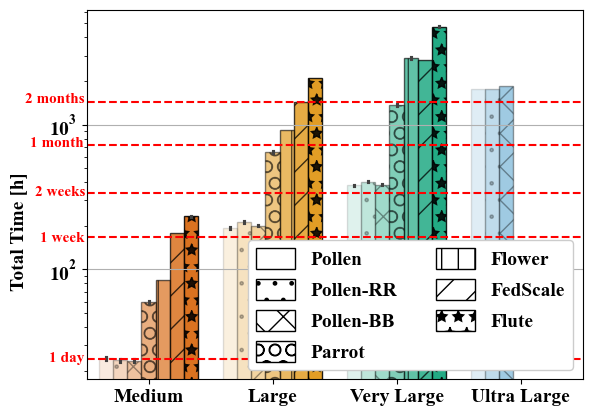

INFO flwr 2024-01-23 00:00:00,523 | 1181468510.py:56 | For Pollen and MLM the mean RCT (100 clients) is 22.73+-4.163063775634479
INFO flwr 2024-01-23 00:00:00,535 | 1181468510.py:56 | For Pollen and MLM the mean RCT (1000 clients) is 224.7066+-5.117628009146425
INFO flwr 2024-01-23 00:00:00,550 | 1181468510.py:56 | For Pollen and MLM the mean RCT (10000 clients) is 2053.7682+-66.4580384058994
INFO flwr 2024-01-23 00:00:00,568 | 1181468510.py:56 | For Pollen-RR and MLM the mean RCT (100 clients) is 24.4136+-2.9728328308197893
INFO flwr 2024-01-23 00:00:00,584 | 1181468510.py:56 | For Pollen-RR and MLM the mean RCT (1000 clients) is 227.426+-3.7260332795078464
INFO flwr 2024-01-23 00:00:00,599 | 1181468510.py:56 | For Pollen-RR and MLM the mean RCT (10000 clients) is 2160.2402+-26.97169078793541
INFO flwr 2024-01-23 00:00:00,613 | 1181468510.py:56 | For Pollen-BB and MLM the mean RCT (100 clients) is 26.7436+-2.21491738897865
INFO flwr 2024-01-23 00:00:00,627 | 1181468510.py:56 | For Pol

Dataset: MLM


INFO flwr 2024-01-23 00:00:00,719 | 1181468510.py:56 | For FedScale and MLM the mean RCT (100 clients) is 237.6646+-44.83102170194206
INFO flwr 2024-01-23 00:00:00,730 | 1181468510.py:56 | For FedScale and MLM the mean RCT (1000 clients) is 1972.4326+-576.823182489435
INFO flwr 2024-01-23 00:00:00,761 | 1181468510.py:56 | For Flute and MLM the mean RCT (100 clients) is 66.9148+-2.921633269251978
INFO flwr 2024-01-23 00:00:00,774 | 1181468510.py:56 | For Flute and MLM the mean RCT (1000 clients) is 821.1604+-21.635051925983447


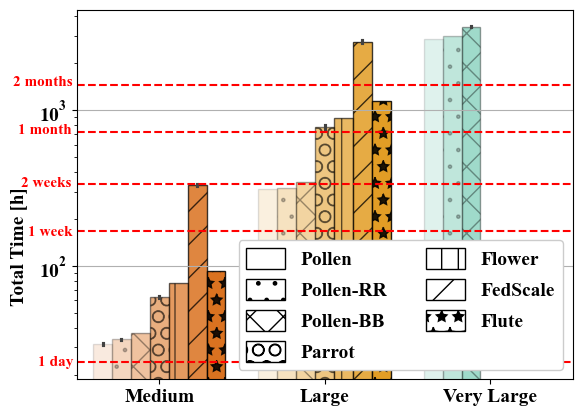

In [22]:
y_axis_label_coord = {
    "IC": [-0.12, 0.4],
    "SR": [-0.12, 0.4],
    "TG": [-0.1, 0.4],
    "MLM": [-0.1, 0.36],
}

texts_coord = {
    "SR": [0.93, 1.0, 1.04, 1.08, 1.12],
    "MLM": [0.86, 0.92, 0.96, 0.98, 1.01],
}

inner_scales = {
    "SR": {
        100: "Medium",
        1_000: "Large",
        2_000: "Very Large",
        10_000: "Ultra Large",
    },
    "MLM": {
        100: "Medium",
        1_000: "Large",
        10_000: "Very Large",
    },
}

# Drawing bar plots for each dataset, hardware setting = 2 and 100 clients per round
current_hardware_setting = 2
for dataset in ["SR", "MLM"]:
    print(f"Dataset: {dataset}")
    dfs: list[pd.DataFrame] = []
    for framework in FRAMEWORKS:
        for n_clients_per_round, scale in inner_scales[dataset].items():
            random.seed(1337)
            tmp_table = (
                results_table.filter(pc.field("framework") == pc.scalar(framework))
                .filter(pc.field("dataset") == pc.scalar(dataset))
                .filter(
                    pc.field("hardware_setting") == pc.scalar(current_hardware_setting)
                )
                .filter(
                    pc.field("n_clients_per_round") == pc.scalar(n_clients_per_round)
                )
                .filter(pc.field("is_dropped") == pc.scalar(False))
            )
            try:
                tmp_dict = {
                    "Round Completion Time [s]": [0.0] * N_TOTAL_ROUNDS,
                    "Round Completion Time [m]": [0.0] * N_TOTAL_ROUNDS,
                    "Round Completion Time [h]": [0.0] * N_TOTAL_ROUNDS,
                    "Framework": [framework] * N_TOTAL_ROUNDS,
                    "Dataset": [dataset] * N_TOTAL_ROUNDS,
                    "Scale (# clients per round)": [scale] * N_TOTAL_ROUNDS,
                }
                if tmp_table.num_rows != 0:
                    tmp_rct = (
                        tmp_table.column("rct")
                        .to_numpy()[1:]
                        .astype("timedelta64[s]")
                        .astype(float)
                    )
                    tmp_rct = random.choices(tmp_rct, k=N_TOTAL_ROUNDS)
                    tmp_dict = {
                        "Round Completion Time [s]": tmp_rct,
                        "Round Completion Time [m]": np.array(tmp_rct) * (1 / 60),
                        "Round Completion Time [h]": np.array(tmp_rct) * (1 / 3600),
                        "Framework": [framework] * N_TOTAL_ROUNDS,
                        "Dataset": [dataset] * N_TOTAL_ROUNDS,
                        "Scale (# clients per round)": [scale] * N_TOTAL_ROUNDS,
                    }
                    log(
                        INFO,
                        f"For {framework} and {dataset} the mean RCT"
                        f" ({n_clients_per_round} clients) is"
                        f" {np.mean(tmp_rct)}+-{np.std(tmp_rct)}",
                    )
                dfs.append(pd.DataFrame.from_dict(tmp_dict))
            except Exception as e:
                print(e)
    df = pd.concat(dfs)
    textures = ["", ".", "x", "O", "|", "/", "*"]
    colors = [
        sns.color_palette("colorblind")[3],
        sns.color_palette("colorblind")[1],
        sns.color_palette("colorblind")[2],
        sns.color_palette("colorblind")[0],
        sns.color_palette("colorblind")[7],
        sns.color_palette("colorblind")[4],
        sns.color_palette("colorblind")[5],
    ]
    alpha_split = 1.0 / (len(df["Framework"].unique()) + 1)
    alphas = [alpha_split * (i + 1) for i in range(len(df["Framework"].unique()))]
    fig, ax = plt.subplots()
    sns.barplot(
        data=df,
        x="Scale (# clients per round)",
        y="Round Completion Time [h]",
        hue="Framework",
        hue_order=FRAMEWORKS,
        errorbar=error_bar_fn_std_based,
        # errorbar=error_bar_fn_min_max,
        estimator=np.sum,
        edgecolor="black",
    )
    split = (
        len(df["Framework"].unique()) * len(df["Scale (# clients per round)"].unique())
        - 1
    )
    for i, patch in enumerate(ax.patches):
        if i > split:
            patch.set_facecolor("w")
            patch.set_hatch(textures[(i - split - 1) % len(textures)])
            patch.set_alpha(1.0)
        else:
            patch.set_facecolor(
                colors[i % (len(df["Scale (# clients per round)"].unique()))]
            )
            patch.set_hatch(
                textures[i // (len(df["Scale (# clients per round)"].unique()))]
            )
            patch.set_alpha(
                alphas[i // (len(df["Scale (# clients per round)"].unique()))]
            )
    y_axis_position = plt.gca().get_position().x0
    plt.axhline(y=24, color="r", linestyle="--")
    plt.text(
        y_axis_position - texts_coord[dataset][0], 23, "1 day", color="r", fontsize=11
    )
    plt.axhline(y=24 * 7, color="r", linestyle="--")
    plt.text(
        y_axis_position - texts_coord[dataset][1],
        (24 * 7) - 12,
        "1 week",
        color="r",
        fontsize=11,
    )
    plt.axhline(y=24 * 14, color="r", linestyle="--")
    plt.text(
        y_axis_position - texts_coord[dataset][2],
        (24 * 14) - 14,
        "2 weeks",
        color="r",
        fontsize=11,
    )
    if dataset == "SR" or dataset == "MLM":
        plt.axhline(y=24 * 30, color="r", linestyle="--")
        plt.text(
            y_axis_position - texts_coord[dataset][3],
            (24 * 30) - 14,
            "1 month",
            color="r",
            fontsize=11,
        )
    plt.axhline(y=24 * 60, color="r", linestyle="--")
    plt.text(
        y_axis_position - texts_coord[dataset][4],
        (24 * 60) - 14,
        "2 months",
        color="r",
        fontsize=11,
    )
    if len(FRAMEWORKS) == 7 and dataset == "TG":
        plt.text(0.90, 79, r"$(\star)$", color="red", fontsize=15)
        plt.text(1.90, 795, r"$(\star)$", color="red", fontsize=15)
    if len(FRAMEWORKS) == 7 and dataset == "IC":
        for i in range(10):
            plt.text(2.078, 15 * (2**i), r"$(\star)$", color="red", fontsize=12)

    y_label = plt.ylabel("Total Time [h]")
    y_label.set_weight("bold")
    ax.yaxis.set_label_coords(
        y_axis_label_coord[dataset][0],
        y_axis_label_coord[dataset][1],
    )
    plt.yscale("log")
    plt.xlabel("")
    legend = plt.legend(handleheight=1.3, loc="lower right", ncols=2)
    legend.set_title("")
    legend.get_frame().set_alpha(1.0)
    plt.grid(axis="y")
    plt.savefig(
        f"scalability_appendix_{dataset.lower()}_rebuttal.pdf",
        format="pdf",
        dpi=800,
        bbox_inches="tight",
    )
    plt.savefig(
        f"scalability_appendix_{dataset.lower()}_rebuttal.png",
        format="png",
        dpi=800,
        bbox_inches="tight",
    )
    plt.show()